In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

from pymargins import GComputation, steps  # 0.4.0: Margins -> GComputation

rng = np.random.default_rng(0)
n = 1500
df = pd.DataFrame({
    "x": rng.normal(0, 1, n),
    "g": rng.integers(0, 50, n),
})
lp = -2.5 + 1.6 * df["x"]
df["y"] = rng.binomial(1, 1 / (1 + np.exp(-lp)))

fit = smf.glm("y ~ x", data=df, family=sm.families.Binomial()).fit()

In [2]:
m = GComputation(fit, at="overall", method="delta", scale="log")
print(m.predict(atexog={"x": [-2, 0, 2]}).summary())

             Graph Result (delta, level=0.95)             
      estimate  std err         z  P>|z|  [95% Conf. Int.]
----------------------------------------------------------
x=-2    0.0029   0.3350  -17.4381  0.000    0.0015, 0.0056
x=0     0.0665   0.1175  -23.0812  0.000    0.0528, 0.0837
x=2     0.6350   0.0614   -7.3963  0.000    0.5630, 0.7162

n = 1500
Note: std err is on the inference scale; estimate and CI are on the reporting scale.
Delta-vs-sim disagreement: 3.590%
plan ce183f2@1 | κ = max 0.107


In [3]:
m_sim = GComputation(fit, at="overall", method="simulation", n_sim=2000, scale="log")
print(m_sim.predict(atexog={"x": [-2, 0, 2]}).summary())

           Graph Result (simulation, level=0.95)           
      estimate  std err  statistic  P>|z|  [95% Conf. Int.]
-----------------------------------------------------------
x=-2    0.0029   0.3286    -5.8416  0.000    0.0015, 0.0054
x=0     0.0665   0.1135    -2.7112  0.000    0.0529, 0.0825
x=2     0.6350   0.0623    -0.4541  0.000    0.5613, 0.7124

n = 1500
Note: std err is on the inference scale; estimate and CI are on the reporting scale.
plan 517b310@1 | κ = max 0.107


In [4]:
m_boot = GComputation(fit, at="overall", method="bootstrap", B=200, scale="log")
print(m_boot.predict(atexog={"x": [-2, 0, 2]}).summary())

/home/hunter/Workspace/pymargins/pymargins/estimators/_base.py:176: SoundnessWarning: [tail_count_low] Bootstrap tail count ≈ 5.0 (< 10) at level=0.95: percentile tails are poorly estimated. Increase B or use ci="se".
  self._plan, self._report, self._compiled = compile(


            Graph Result (bootstrap, level=0.95)           
      estimate  std err  statistic  P>|z|  [95% Conf. Int.]
-----------------------------------------------------------
x=-2    0.0029   0.3341    -5.8416  0.000    0.0014, 0.0050
x=0     0.0665   0.1155    -2.7112  0.000    0.0511, 0.0815
x=2     0.6350   0.0631    -0.4541  0.000    0.5601, 0.6984

n = 1500
Note: std err is on the inference scale; estimate and CI are on the reporting scale.
plan ff00ef1@1 | κ = max 0.107


In [5]:
m_clust = GComputation(
    steps.input(df, cluster=df["g"].values),
    outcome=fit,
    at="overall",
    method="bootstrap",
    B=500,
    scale="log",
)
print(m_clust.predict(atexog={"x": [-2, 0, 2]}).summary())

            Graph Result (bootstrap, level=0.95)           
      estimate  std err  statistic  P>|z|  [95% Conf. Int.]
-----------------------------------------------------------
x=-2    0.0029   0.3182    -5.8416  0.000    0.0016, 0.0051
x=0     0.0665   0.1155    -2.7112  0.000    0.0521, 0.0815
x=2     0.6350   0.0567    -0.4541  0.000    0.5625, 0.7102

n = 1500
Note: std err is on the inference scale; estimate and CI are on the reporting scale.
plan 493b9ad@1 | κ = max 0.102


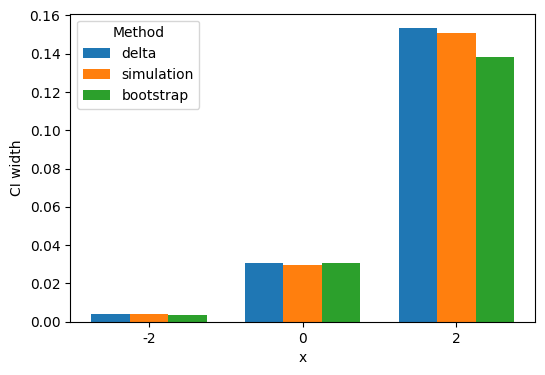

In [6]:
import matplotlib.pyplot as plt

x_grid = [-2, 0, 2]
res_delta = m.predict(atexog={"x": x_grid}).to_frame()
res_sim = m_sim.predict(atexog={"x": x_grid}).to_frame()
res_boot = m_boot.predict(atexog={"x": x_grid}).to_frame()

fig, ax = plt.subplots(figsize=(6, 4))
widths = {
    "delta": res_delta["ci_upper"] - res_delta["ci_lower"],
    "simulation": res_sim["ci_upper"] - res_sim["ci_lower"],
    "bootstrap": res_boot["ci_upper"] - res_boot["ci_lower"],
}
x_pos = np.arange(len(x_grid))
width = 0.25
for i, (label, w) in enumerate(widths.items()):
    ax.bar(x_pos + i * width, w, width, label=label)
ax.set_xticks(x_pos + width)
ax.set_xticklabels([str(v) for v in x_grid])
ax.set(xlabel="x", ylabel="CI width")
ax.legend(title="Method")